# cluster2x2 results

Plots for `scripts/cluster2x2_run.py` output (HDF5 or text files).

In [6]:
import shlex
import os
import numpy as np
import matplotlib.pyplot as plt

PARAM_FILE   = 'param.in'   # relative to scripts/
SCRIPT_DIR   = os.path.dirname(os.path.abspath(PARAM_FILE)) if '__file__' not in dir() else os.path.dirname(os.path.abspath('__file__'))

# --- parse param.in to find output_dir / output_name / simple_output ---
params = {}
with open(PARAM_FILE) as f:
    for line in f:
        line = line.split('#', 1)[0].strip()
        if line:
            tok = shlex.split(line)
            if len(tok) >= 2 and tok[0].startswith('--'):
                params[tok[0][2:]] = tok[1]
            elif len(tok) == 1 and tok[0].startswith('--'):
                params[tok[0][2:]] = True

t_max       = float(params.get('t_max', 10.0))
n_t         = int(params.get('n_t', 51))
output_dir  = params.get('output_dir', 'data/cluster2x2')
output_name = params.get('output_name', 'cluster2x2')
simple_output = params.get('simple_output', False)

t = np.linspace(0, t_max, n_t)

os.makedirs(os.path.join(output_dir, 'plots'), exist_ok=True)
plots_dir = os.path.join(output_dir, 'plots')

print(f'output_dir:  {output_dir}')
print(f'output_name: {output_name}')
print(f'simple_output: {simple_output}')

output_dir:  data/cluster2x2
output_name: cluster2x2
simple_output: False


In [7]:
# ---------------------------------------------------------------
# Load data
# ---------------------------------------------------------------

def load_txt(path):
    """Load a 4-column text file: Re(FF) Im(FF) Re(FB) Im(FB)."""
    d = np.loadtxt(path)
    return d[:, 0] + 1j*d[:, 1], d[:, 2] + 1j*d[:, 3]  # G_FF, G_FB


if simple_output:
    # ---- text file mode ----
    g_ref_FF, g_ref_FB = load_txt(os.path.join(output_dir, 'tddt_ref_sys_t0_00.txt'))
    g_loc_FF, g_loc_FB = load_txt(os.path.join(output_dir, 'tddt_t0_loc.txt'))
    g_cpt_FF, g_cpt_FB = load_txt(os.path.join(output_dir, 'tddt_CPT.txt'))
    sig_FF,   sig_FB   = load_txt(os.path.join(output_dir, 'sigma_dual.txt'))

    n_k_files = sum(1 for fn in os.listdir(output_dir) if fn.startswith('tddt_T_t0_k'))
    g_k_FF = []
    g_k_FB = []
    for ki in range(n_k_files):
        ff, fb = load_txt(os.path.join(output_dir, f'tddt_T_t0_k{ki}.txt'))
        g_k_FF.append(ff); g_k_FB.append(fb)

    g_d0_r0_FF, g_d0_r0_FB = load_txt(os.path.join(output_dir, 'tddt_Gd0_R_k0.txt'))
    g_d0_r1_FF, g_d0_r1_FB = load_txt(os.path.join(output_dir, 'tddt_Gd0_R_k1.txt'))

else:
    # ---- HDF5 mode ----
    import h5py

    h5_path = os.path.join(output_dir, output_name + '.h5')
    with h5py.File(h5_path, 'r') as f:
        t = f['t_mesh'][()]
        n_t = len(t)

        def load_h5_gf(grp, name, tidx0=0, tidx1=slice(None), extra=()):
            """Load G(t'=t[tidx0], t) slice from HDF5 dataset.
            extra: additional index tuple applied after time axes."""
            ff = grp[name]['FF'][tidx0, tidx1][extra]
            fb = grp[name]['FB'][tidx0, tidx1][extra]
            return ff, fb

        g_ref_FF, g_ref_FB = load_h5_gf(f['ref'], 'g_ref', extra=(0,0,0,0))
        g_imp_FF, g_imp_FB = load_h5_gf(f['ref'], 'g_imp', extra=(0,0,0,0))

        sig_FF,   sig_FB   = load_h5_gf(f['dual'], 'Sigma_loc', extra=(0,0,0,0))

        g_loc_FF, g_loc_FB = load_h5_gf(f['lattice'], 'g_loc',     extra=(0,0,0,0))
        g_cpt_FF, g_cpt_FB = load_h5_gf(f['lattice'], 'g_cpt_loc', extra=(0,0,0,0))

        # k-resolved: shape (n_t, n_t, n_k, *target_shape)
        n_k_tot = f['lattice']['g_k']['FF'].shape[2]
        g_k_FF = [f['lattice']['g_k']['FF'][0, :, ki, 0, 0, 0, 0] for ki in range(n_k_tot)]
        g_k_FB = [f['lattice']['g_k']['FB'][0, :, ki, 0, 0, 0, 0] for ki in range(n_k_tot)]

        # gd0 real-space: shape (n_t, n_t, n_r, *target_shape)
        g_d0_r0_FF = f['lattice']['gd0_r']['FF'][0, :, 0, 0, 0, 0, 0]
        g_d0_r0_FB = f['lattice']['gd0_r']['FB'][0, :, 0, 0, 0, 0, 0]
        g_d0_r1_FF = f['lattice']['gd0_r']['FF'][0, :, 1, 0, 0, 0, 0]
        g_d0_r1_FB = f['lattice']['gd0_r']['FB'][0, :, 1, 0, 0, 0, 0]

print('Data loaded.')

Data loaded.


In [8]:
# ---------------------------------------------------------------
# Helper
# ---------------------------------------------------------------

def plot_gf(ax_re, ax_im, t, data_dict, title=''):
    """Plot Re/Im of several G(t, t'=0) on two axes."""
    for label, (ff, fb) in data_dict.items():
        ax_re.plot(t, ff.real, label=f'{label} FF')
        ax_re.plot(t, fb.real, ls='--', label=f'{label} FB')
        ax_im.plot(t, ff.imag, label=f'{label} FF')
        ax_im.plot(t, fb.imag, ls='--', label=f'{label} FB')
    ax_re.set_ylabel('Re G')
    ax_im.set_ylabel('Im G')
    ax_im.set_xlabel('t')
    ax_re.legend(fontsize=7)
    ax_im.legend(fontsize=7)
    if title:
        ax_re.set_title(title)

ValueError: x and y must have same first dimension, but have shapes (51,) and (4,)

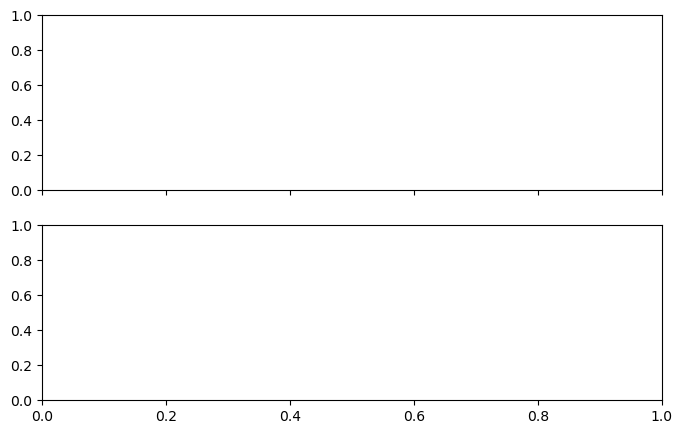

In [9]:
# ---------------------------------------------------------------
# Reference system GF
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
plot_gf(axes[0], axes[1], t,
        {'g_ref': (g_ref_FF, g_ref_FB)},
        title='Reference system  G_ref(t, t\'=0)')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'g_ref.png'), dpi=150)
plt.show()

In [ ]:
# ---------------------------------------------------------------
# Dual self-energy (local)
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
plot_gf(axes[0], axes[1], t,
        {'Sigma_loc': (sig_FF, sig_FB)},
        title='Dual self-energy Σ_loc(t, t\'=0)')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'sigma_dual_loc.png'), dpi=150)
plt.show()

In [ ]:
# ---------------------------------------------------------------
# Lattice GF: local vs CPT
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
plot_gf(axes[0], axes[1], t,
        {'G_loc': (g_loc_FF, g_loc_FB),
         'G_CPT': (g_cpt_FF, g_cpt_FB)},
        title='Lattice GF  G_loc vs G_CPT  (t, t\'=0)')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'g_lattice_local.png'), dpi=150)
plt.show()

In [ ]:
# ---------------------------------------------------------------
# k-resolved lattice GF
# ---------------------------------------------------------------
n_k_tot = len(g_k_FF)
fig, axes = plt.subplots(2, n_k_tot, figsize=(4*n_k_tot, 5), sharex=True, sharey='row')
if n_k_tot == 1:
    axes = axes[:, np.newaxis]
for ki in range(n_k_tot):
    axes[0, ki].plot(t, g_k_FF[ki].real, label='FF')
    axes[0, ki].plot(t, g_k_FB[ki].real, ls='--', label='FB')
    axes[1, ki].plot(t, g_k_FF[ki].imag, label='FF')
    axes[1, ki].plot(t, g_k_FB[ki].imag, ls='--', label='FB')
    axes[0, ki].set_title(f'k-point {ki}')
    axes[0, ki].legend(fontsize=7)
    axes[1, ki].set_xlabel('t')
axes[0, 0].set_ylabel('Re G_k')
axes[1, 0].set_ylabel('Im G_k')
fig.suptitle('k-resolved G_lattice(t, t\'=0)', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'g_k_resolved.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ---------------------------------------------------------------
# Bare dual propagator Gd0 (real-space r0, r1)
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
plot_gf(axes[0], axes[1], t,
        {'Gd0 r0': (g_d0_r0_FF, g_d0_r0_FB),
         'Gd0 r1': (g_d0_r1_FF, g_d0_r1_FB)},
        title='Bare dual propagator Gd0(t, t\'=0)')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'gd0_real_space.png'), dpi=150)
plt.show()